## Problem Statement
Chest X-ray analysis is widely used to detect lung diseases, but manual interpretation is:

Time-consuming
Requires expert radiologists
## Need
A system that can:

Automatically analyze X-ray images
Assist in detecting diseases
Reduce diagnostic workload

## Project Objectives
The system should:

Analyze chest X-ray images automatically
Detect lung disease patterns
Classify images into:
COVID / PNEUMONIA / NORMAL
Assist medical professionals in faster screening
## Important Point
Not a replacement for doctors

## Approach Overview
Traditional rule-based image processing methods are not sufficient for complex medical image patterns.

## Traditional Methods
Handcrafted filters & rules
Limited to known patterns
Cannot generalize well
Manual feature design needed
## CNN-Based Approach
Learns patterns from data
Extracts spatial features
Generalizes to new images
No manual feature design


## Import Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch.optim as optim

## Data Loading

Download and extract the chest X-ray dataset from S3.

In [ ]:
import zipfile
import os

!wget "https://s3.ap-south-1.amazonaws.com/new-assets.ccbp.in/frontend/content/aiml/CV/Image_Dataset.zip"

with zipfile.ZipFile("Image_Dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

--2026-05-11 18:11:00--  https://s3.ap-south-1.amazonaws.com/new-assets.ccbp.in/frontend/content/aiml/CV/Image_Dataset.zip
Resolving s3.ap-south-1.amazonaws.com (s3.ap-south-1.amazonaws.com)... 16.12.36.85, 3.5.211.87, 16.12.36.81, ...
Connecting to s3.ap-south-1.amazonaws.com (s3.ap-south-1.amazonaws.com)|16.12.36.85|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 290862263 (277M) [application/zip]
Saving to: ‘Image_Dataset.zip’

Image_Dataset.zip   100%[===================>] 277.39M  16.6MB/s    in 19s     

2026-05-11 18:11:20 (14.8 MB/s) - ‘Image_Dataset.zip’ saved [290862263/290862263]



### Dataset Overview

The dataset is organized into 3 folders:
- COVID — 1626 images
- NORMAL — 1802 images
- PNEUMONIA — 1800 images

All images are 256x256 grayscale PNG chest X-ray scans.

In [ ]:
print(os.listdir("dataset"))

['NORMAL', 'PNEUMONIA', 'COVID']


### Build DataFrame

Iterate through each class folder and collect image paths with labels.

In [ ]:
dataset_path = "dataset"

data = []

for label in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, label)
    for img in os.listdir(class_path):
        img_path = os.path.join(class_path, img)
        data.append([img_path, label])

In [ ]:
df = pd.DataFrame(data, columns=["image_path", "label"])

In [ ]:
df.head()

,image_path,label
0,dataset/NORMAL/NORMAL_641.png,NORMAL
1,dataset/NORMAL/NORMAL_1614.png,NORMAL
2,dataset/NORMAL/NORMAL_892.png,NORMAL
3,dataset/NORMAL/NORMAL_1735.png,NORMAL
4,dataset/NORMAL/NORMAL_372.png,NORMAL


### Check the Data

In [ ]:
print("Total images:", len(df))
print(df["label"].value_counts())

Total images: 5228
label
NORMAL       1802
PNEUMONIA    1800
COVID        1626
Name: count, dtype: int64


## Visualise Sample Images

We inspect a few images to confirm correct loading and labeling.
Balanced sampling ensures all classes are visible.

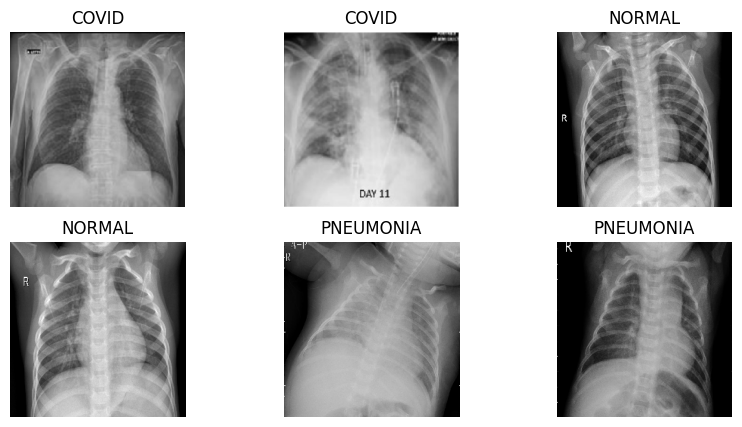

In [ ]:
plt.figure(figsize=(10, 5))

classes = ["COVID", "NORMAL", "PNEUMONIA"]
i = 1

for cls in classes:
    sample_df = df[df["label"] == cls].sample(2)

    for _, row in sample_df.iterrows():
        img = Image.open(row["image_path"])

        plt.subplot(2, 3, i)
        plt.imshow(img, cmap='gray')
        plt.title(row["label"])
        plt.axis('off')

        i += 1

plt.show()

## Dataset Split

We split into training (80%) and validation (20%) with stratification to preserve class balance.

In [ ]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

In [ ]:
print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 4182
Validation size: 1046


### Check Distribution

In [ ]:
print(train_df["label"].value_counts())
print(val_df["label"].value_counts())

label
NORMAL       1441
PNEUMONIA    1440
COVID        1301
Name: count, dtype: int64
label
NORMAL       361
PNEUMONIA    360
COVID        325
Name: count, dtype: int64


## Preprocessing

We prepare images before feeding into the model:
- Resize to 224x224 - standard input size for the CNN
- Grayscale - single channel input
- Normalize (0-1) - scales pixel values for stable training

In [ ]:
IMG_SIZE = 224

def preprocess_image(img_path):
    img = Image.open(img_path).convert("L")   # grayscale
    img = img.resize((IMG_SIZE, IMG_SIZE))     # resize
    img = np.array(img) / 255.0               # normalize (0-1)
    return img

In [ ]:
sample_img = preprocess_image(train_df["image_path"].iloc[0])

In [ ]:
print(sample_img.shape)

(224, 224)


### Visualize Processed Image

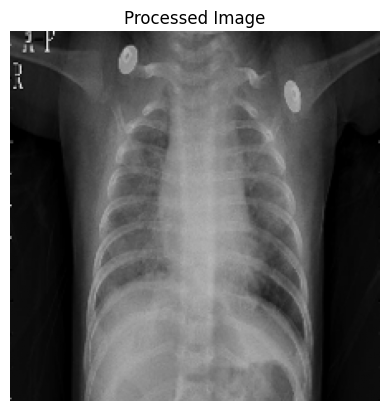

In [ ]:
plt.imshow(sample_img, cmap='gray')
plt.title("Processed Image")
plt.axis('off')
plt.show()

## Label Encoding

Models need numbers, not text. We map each class to an integer.

In [ ]:
label_map = {
    "COVID": 0,
    "NORMAL": 1,
    "PNEUMONIA": 2
}

## Custom Dataset

We create a custom dataset class that loads and preprocesses images on demand.
- Input: image file path
- Output: (image_tensor, label_tensor)

In [ ]:
class XrayDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        label = self.df.loc[idx, "label"]

        img = Image.open(img_path).convert("L")
        img = img.resize((224, 224))
        img = np.array(img) / 255.0
        img = np.expand_dims(img, axis=0)

        img = torch.tensor(img, dtype=torch.float32)
        label = torch.tensor(label_map[label], dtype=torch.long)

        return img, label

### Verify Dataset Loading

In [ ]:
train_dataset = XrayDataset(train_df)

img, label = train_dataset[0]

In [ ]:
print(img.shape)   # (1, 224, 224)
print(label)

torch.Size([1, 224, 224])
tensor(2)


## Create DataLoader

DataLoader groups images into batches for efficient training.
- Batch size = 32
- shuffle=True for training, False for validation

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [ ]:
val_dataset = XrayDataset(val_df)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### Verify Batch Shape

In [ ]:
for images, labels in train_loader:
    print(images.shape)   # (32, 1, 224, 224)
    print(labels.shape)   # (32,)
    break

torch.Size([32, 1, 224, 224])
torch.Size([32])


## CNN Model Architecture

The model consists of two main parts:
- Feature Extraction — convolution layers learn patterns from X-ray images
- Classification — fully connected layers predict the final class

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # Fully connected
        self.fc1 = nn.Linear(128 * 28 * 28, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 3)

        self.relu = nn.ReLU()

    def forward(self, x):
        # Block 1
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)

        # Block 2
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.pool(x)

        # Block 3
        x = self.relu(self.conv5(x))
        x = self.pool(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

## Initialize Model

Model Flow:
```
Input (1, 224, 224)
-> Conv(32) -> ReLU -> Conv(32) -> ReLU -> MaxPool
-> Conv(64) -> ReLU -> Conv(64) -> ReLU -> MaxPool
-> Conv(128) -> ReLU -> MaxPool
-> Flatten -> Dense(128) -> Dropout(0.5) -> Output(3)
```

In [ ]:
model = SimpleCNN()

In [ ]:
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
  (relu): ReLU()
)


### Test with One Batch

Output has 3 neurons (COVID, NORMAL, PNEUMONIA) producing raw scores.
Softmax is applied automatically inside the loss function.

In [ ]:
for images, labels in train_loader:
    outputs = model(images)
    print(outputs.shape)   # (batch_size, 3)
    break

torch.Size([32, 3])


## Training Setup

### Loss Function

CrossEntropyLoss - standard for multi-class classification.

In [ ]:
criterion = nn.CrossEntropyLoss()

### Optimizer

Adam with learning rate 0.001, adaptive learning rates for faster convergence.

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Device

Use GPU if available for faster training.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
  (relu): ReLU()
)

In [ ]:
print(device)

cuda


---
# Train the Model

We train the model for 16 epochs.
- One epoch = model sees all training images once
- After each epoch, we evaluate on validation data
- We track train loss, train accuracy, val loss, and val accuracy

## Saving the Best Model

During training, we save the model only when validation accuracy improves.
- The model changes every epoch and best performance may occur in the middle, not at the end
- Without checkpointing, we would be stuck with the last epoch which may be overfitted
- The saved file (best_model.pth) always contains the best-performing version

In [ ]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

epochs = 16
best_val_acc = 0

for epoch in range(epochs):
    model.train()

    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = train_loss / len(train_loader)
    train_acc = correct / total

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch [1/16] | Train Loss: 0.1638 | Train Acc: 0.9455 | Val Loss: 0.1537 | Val Acc: 0.9465
Epoch [2/16] | Train Loss: 0.1277 | Train Acc: 0.9574 | Val Loss: 0.1453 | Val Acc: 0.9560
Epoch [3/16] | Train Loss: 0.1023 | Train Acc: 0.9644 | Val Loss: 0.1211 | Val Acc: 0.9665
Epoch [4/16] | Train Loss: 0.0875 | Train Acc: 0.9677 | Val Loss: 0.1368 | Val Acc: 0.9665
Epoch [5/16] | Train Loss: 0.0747 | Train Acc: 0.9761 | Val Loss: 0.1157 | Val Acc: 0.9665
Epoch [6/16] | Train Loss: 0.0596 | Train Acc: 0.9804 | Val Loss: 0.1242 | Val Acc: 0.9675
Epoch [7/16] | Train Loss: 0.0492 | Train Acc: 0.9849 | Val Loss: 0.1359 | Val Acc: 0.9637
Epoch [8/16] | Train Loss: 0.0398 | Train Acc: 0.9847 | Val Loss: 0.1640 | Val Acc: 0.9598
Epoch [9/16] | Train Loss: 0.0341 | Train Acc: 0.9880 | Val Loss: 0.1882 | Val Acc: 0.9579
Epoch [10/16] | Train Loss: 0.0360 | Train Acc: 0.9890 | Val Loss: 0.1208 | Val Acc: 0.9694
Epoch [11/16] | Train Loss: 0.0235 | Train Acc: 0.9914 | Val Loss: 0.1748 | Val Acc: 0.97

## Validation Accuracy

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

In [ ]:
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 95.41%


## Collect Predictions

In [ ]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

### Accuracy

In [ ]:
acc = accuracy_score(all_labels, all_preds)
print("Accuracy:", acc)

Accuracy: 0.9541108986615678


## Training Curves

Plotting loss and accuracy over each epoch.

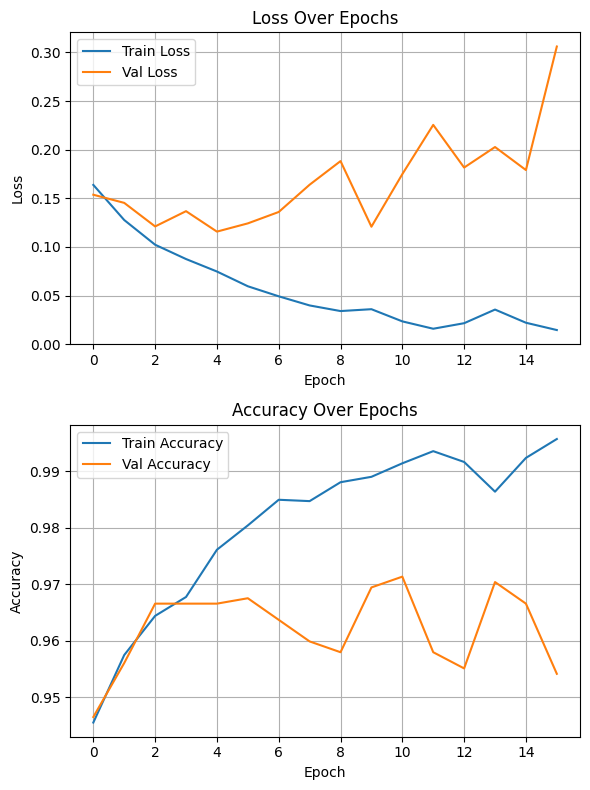

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_title('Loss Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history['train_acc'], label='Train Accuracy')
ax2.plot(history['val_acc'], label='Val Accuracy')
ax2.set_title('Accuracy Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Confusion Matrix

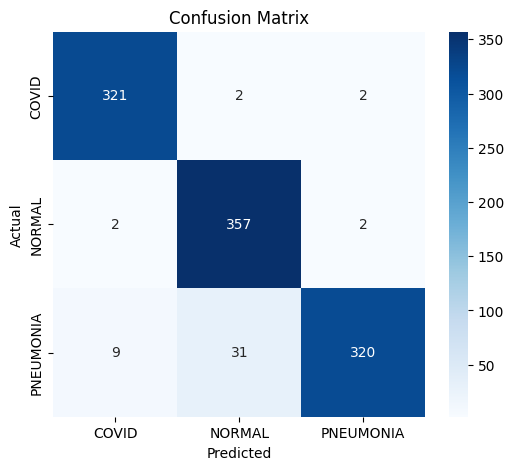

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["COVID", "NORMAL", "PNEUMONIA"],
            yticklabels=["COVID", "NORMAL", "PNEUMONIA"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Classification Report

In [ ]:
print(classification_report(all_labels, all_preds,
                            target_names=["COVID", "NORMAL", "PNEUMONIA"]))

              precision    recall  f1-score   support

       COVID       0.97      0.99      0.98       325
      NORMAL       0.92      0.99      0.95       361
   PNEUMONIA       0.99      0.89      0.94       360

    accuracy                           0.95      1046
   macro avg       0.96      0.96      0.95      1046
weighted avg       0.96      0.95      0.95      1046



## Visualise Predictions

Compare the model's predictions with true labels.
Green title = correct, Red title = wrong.

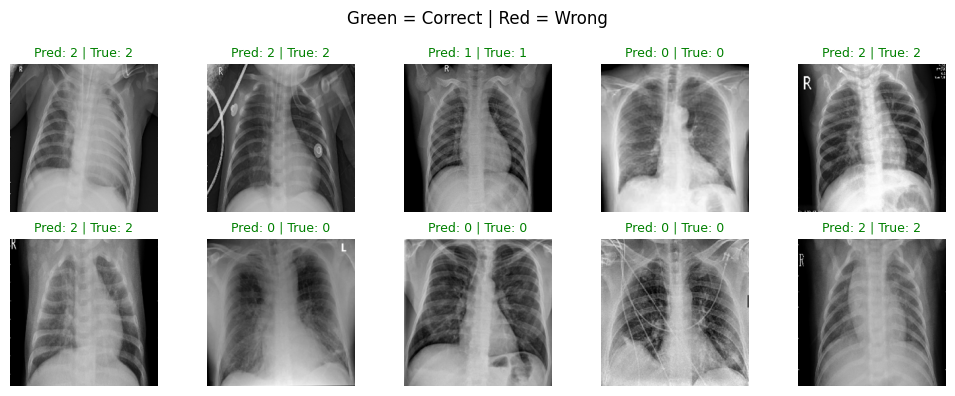

In [ ]:
import random

model.eval()

images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    img = images[i].cpu().squeeze()
    ax.imshow(img, cmap='gray')

    color = 'green' if preds[i] == labels[i] else 'red'
    ax.set_title(
        f"Pred: {preds[i].item()} | True: {labels[i].item()}",
        color=color, fontsize=9
    )
    ax.axis('off')

plt.suptitle("Green = Correct | Red = Wrong", fontsize=12)
plt.tight_layout()
plt.show()

# Testing on Unseen Data

We test the model on completely unseen images to simulate real-world usage.
These images were not used during training or validation.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Unseen_Data.zip to Unseen_Data (1).zip


In [ ]:
import zipfile

zip_path = "/content/Unseen_Data.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("unseen_data")

print(os.listdir("unseen_data"))

['Covid-Unseen-Data', 'Pneumonia-Unseen-Data', 'Normal-Unseen-Data']


### Prepare Unseen Data

Convert the folder-based dataset into a structured DataFrame for prediction.

In [ ]:
print(os.listdir("unseen_data"))

['Covid-Unseen-Data', 'Pneumonia-Unseen-Data', 'Normal-Unseen-Data']


In [ ]:
dataset_path = "unseen_data"

data = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if not os.path.isdir(folder_path):
        continue

    if "covid" in folder.lower():
        label = "COVID"
    elif "normal" in folder.lower():
        label = "NORMAL"
    elif "pneumonia" in folder.lower():
        label = "PNEUMONIA"
    else:
        continue

    for img in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img)
        if os.path.isfile(img_path):
            data.append([img_path, label])

unseen_df = pd.DataFrame(data, columns=["image_path", "label"])
unseen_df.head()

,image_path,label
0,unseen_data/Covid-Unseen-Data/covid_644.png,COVID
1,unseen_data/Covid-Unseen-Data/covid_1549.png,COVID
2,unseen_data/Covid-Unseen-Data/covid_2059.png,COVID
3,unseen_data/Covid-Unseen-Data/covid_3182.png,COVID
4,unseen_data/Covid-Unseen-Data/covid_229.png,COVID


In [ ]:
label_map = {"COVID": 0, "NORMAL": 1, "PNEUMONIA": 2}
unseen_df["label"] = unseen_df["label"].map(label_map)

### Visualise Model Generalization

Test on unseen images and compare predictions with true labels.

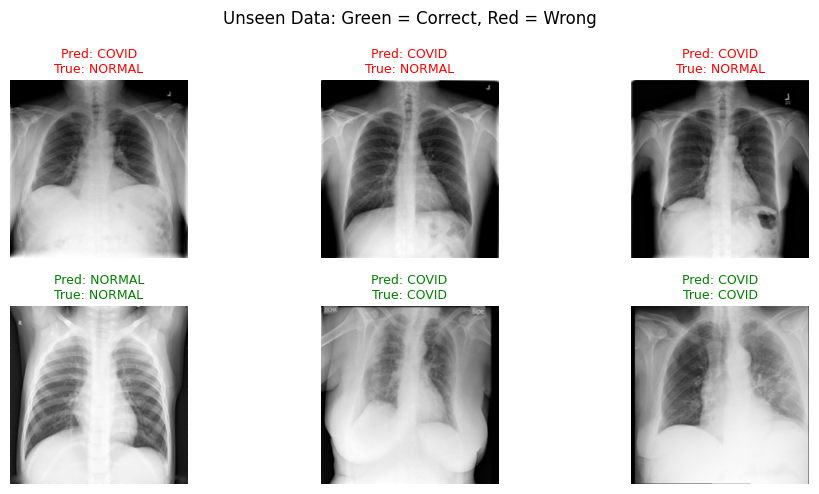

In [ ]:
label_names = ["COVID", "NORMAL", "PNEUMONIA"]

model.eval()

plt.figure(figsize=(10, 5))

indices = random.sample(range(len(unseen_df)), 6)

for i, idx in enumerate(indices):
    img_path = unseen_df["image_path"][idx]
    true_label = unseen_df["label"][idx]

    img = Image.open(img_path).convert("L")
    img = img.resize((224, 224))

    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    img_array = np.expand_dims(img_array, axis=0)

    img_tensor = torch.tensor(img_array, dtype=torch.float32).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        pred = torch.argmax(output, dim=1).item()

    color = "green" if pred == true_label else "red"

    plt.subplot(2, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(
        f"Pred: {label_names[pred]}\nTrue: {label_names[true_label]}",
        color=color, fontsize=9
    )
    plt.axis('off')

plt.suptitle("Unseen Data: Green = Correct, Red = Wrong")
plt.tight_layout()
plt.show()

## Save the Model

Save the trained model weights for reuse without retraining.

In [ ]:
torch.save(model.state_dict(), "xray_cnn_model.pth")
print("Model saved successfully!")

Model saved successfully!


## Conclusion



We built an end-to-end medical image classification system that takes raw chest X-ray images, preprocesses them, trains a CNN model, and predicts whether a patient has COVID, Pneumonia, or is Normal. This capstone covered the complete ML pipeline from data loading to real-world testing.

Try experimenting further:
- Adjust the number of epochs or learning rate and observe how performance changes
- Add more convolutional layers or change filter sizes to see their effect
- Test with your own chest X-ray images to check how the model performs


